In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import MiniBatchKMeans
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from functions import clean_data, split_data
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

In [3]:
df = pd.read_csv("claims_train.csv")

df['VehIsregular'] = (df['VehGas'] == 'Regular').astype(int)

df = df.drop(columns= ['VehGas', 'IDpol'])

def letter_to_index(letter):
    return ord(letter.upper()) - ord('A')

df['Area'] = df['Area'].apply(letter_to_index)

# df = pd.get_dummies(df)

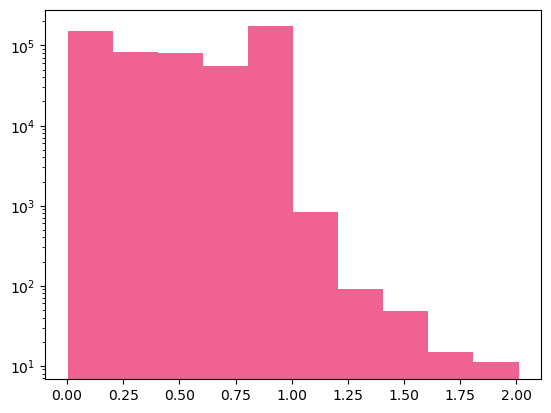

In [4]:
plt.hist(df['Exposure'], log= 'y', color='#F06292')
plt.show()

In [5]:
df['Exposure'] = df['Exposure'].apply(lambda x: x - 1 if x > 1 else x)

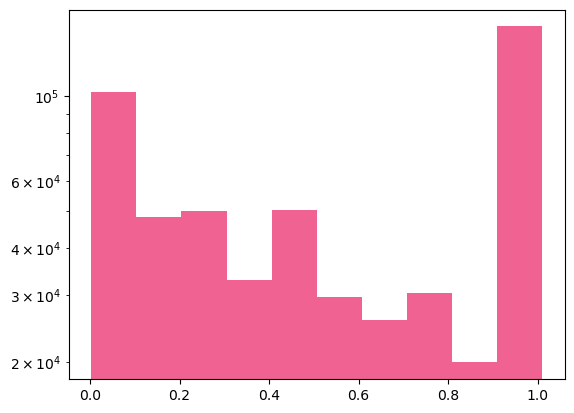

In [6]:
plt.hist(df['Exposure'], log= 'y', color='#F06292')
plt.show()

In [8]:
df.head()

,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,Density,Region,VehIsregular
0,0,0.43,3,7,18,36,95,B1,1054,R24,1
1,0,0.10,3,7,17,80,95,B2,598,R25,1
2,0,0.33,4,7,3,36,76,B6,4172,R82,1
3,0,0.56,0,5,4,73,52,B13,15,R24,0
4,0,0.27,4,8,0,37,50,B11,3021,R53,0


In [9]:
df.shape

(542410, 11)

In [10]:
df = df.dropna()

In [11]:
df.shape

(542410, 11)

<Figure size 1000x800 with 0 Axes>

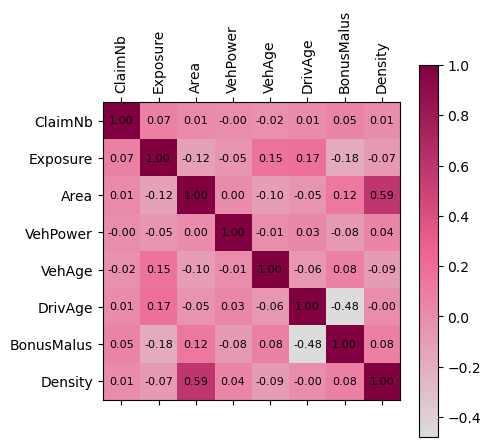

In [12]:
df_numerical = df.drop(columns=['VehBrand', 'Region', 'VehIsregular'])
corr = df_numerical.corr()

colors = ["#dcdcdc", "#F06292", "#800040"]
cmap = LinearSegmentedColormap.from_list("custom_pink", colors, N=256)

plt.figure(figsize=(10, 8))
plt.matshow(corr, cmap=cmap)

plt.xticks(range(len(df_numerical.columns)), df_numerical.columns, rotation=90)
plt.yticks(range(len(df_numerical.columns)), df_numerical.columns)
plt.colorbar()

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        value = corr.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha='center', va='center', color='black', fontsize=8)

plt.savefig("correlation_matrix.png", dpi=300, bbox_inches='tight')

plt.show()

Clustering

In [44]:
X, Y = clean_data("claims_train.csv")

In [42]:

n_samples = X.shape[0]
sil_sample = min(5000, n_samples)

scores = []
for k in range(2, 10):
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        batch_size=4096,        
        max_iter=100,           
        random_state=42,
        n_init="auto"           
    )
    labels = kmeans.fit_predict(X)
    s = silhouette_score(
        X,
        labels,
        sample_size=sil_sample,
        random_state=42
    )
    scores.append((k, s))

for k, s in scores:
    print(f"k={k}: silhouette={s:.4f}")



k=2: silhouette=0.2816
k=3: silhouette=0.0702
k=4: silhouette=0.0684
k=5: silhouette=0.0365
k=6: silhouette=0.0476
k=7: silhouette=0.0674
k=8: silhouette=0.1062
k=9: silhouette=0.1160


In [46]:
y = Y.values.reshape(-1, 1)
n_samples = y.shape[0]
sil_sample = min(5000, n_samples)

for k in range(2,10):
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        batch_size=4096,
        max_iter=100,
        random_state=42,
        n_init="auto"
    )
    labels = kmeans.fit_predict(y)
    s = silhouette_score(
        y,
        labels,
        sample_size=sil_sample,
        random_state=42
    )
    
    print(f"k={k}: silhouette={s:.6f}")

k=2: silhouette=0.994983
k=3: silhouette=0.994983
k=4: silhouette=0.994983
k=5: silhouette=0.994983
k=6: silhouette=0.994983
k=7: silhouette=0.994983
k=8: silhouette=0.994983
k=9: silhouette=0.994983


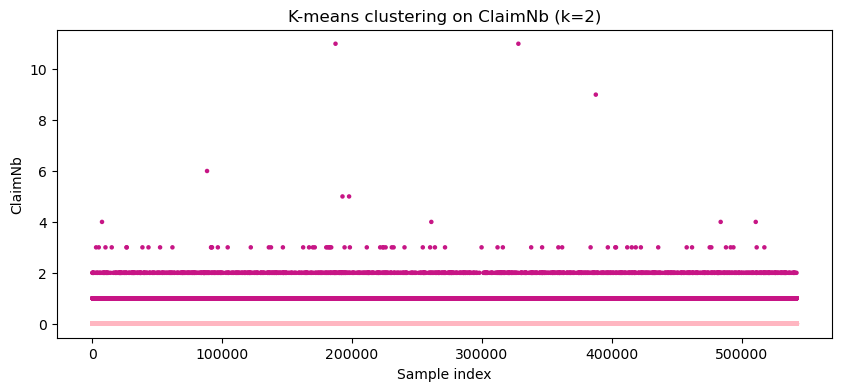

In [ ]:
pink_shades = ["#ffb6c1", "#ff69b4", "#ff1493", "#db7093", "#c71585"]
pink_cmap = mcolors.ListedColormap(pink_shades)

k = 2
plt.figure(figsize=(10, 4))
plt.scatter(np.arange(len(y)), y, c=labels, cmap = pink_cmap, s=5)
plt.title(f"K-means clustering on ClaimNb (k={k})")
plt.xlabel("Sample index")
plt.ylabel("ClaimNb")
plt.show()

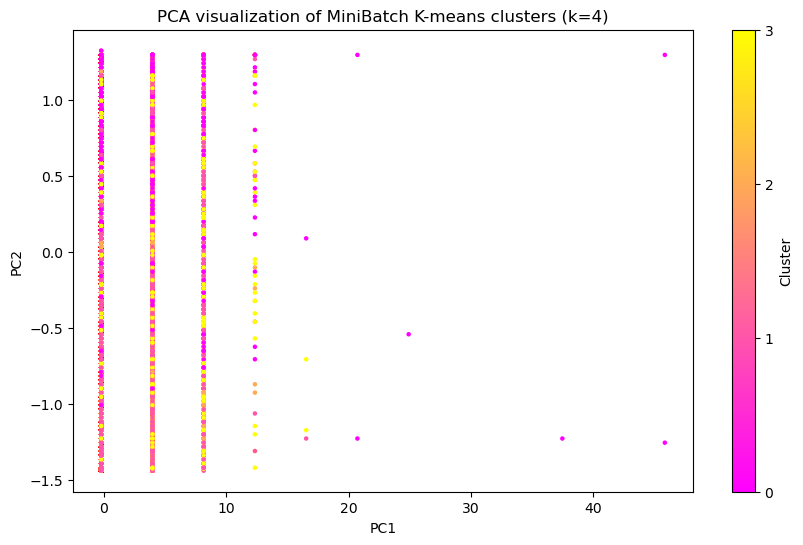

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

k = 4
kmeans = MiniBatchKMeans(
    n_clusters=k,
    batch_size=4096,
    max_iter=200,
    random_state=42
).fit(X_scaled)

labels = kmeans.labels_





plt.figure(figsize=(10,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap="spring", s=5)
plt.title(f"PCA visualization of MiniBatch K-means clusters (k={k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(ticks=[0, 1, 2, 3], label = "Cluster")
plt.show()


In [16]:
# X_reduced = np.load("X_reduced.npy")

# features = df_numerical.drop(columns = "ClaimNb")
# target = df_numerical["ClaimNb"]

# n_samples = X_reduced.shape[0]
# sil_sample = min(5000, n_samples)

# scores = []
# for k in range(2, 10):
#     kmeans = MiniBatchKMeans(
#         n_clusters=k,
#         batch_size=4096,       
#         max_iter=100,          
#         random_state=42,
#         n_init="auto"           
#     )
#     labels = kmeans.fit_predict(X_reduced)
#     s = silhouette_score(
#         X_reduced,
#         labels,
#         sample_size=sil_sample,
#         random_state=42    
#     )
#     scores.append((k, s))

# for k, s in scores:
#     print(f"k={k}: silhouette={s:.4f}")



PCA

In [17]:
X, Y = clean_data("claims_train.csv")

X_train, X_val, y_train, y_val = split_data(X, Y, 0.2)

In [38]:
# Keep all components (baseline)
pca_all = PCA()
X_all = pca_all.fit_transform(X)
print("All components:", X_all.shape)
print("Variance explained (should be 1.0):", np.round(pca_all.explained_variance_ratio_.sum(), 3))

# Keep enough for 95% variance
pca95 = PCA(n_components=0.95)
X_95 = pca95.fit_transform(X)
print("\n95% variance:")
print("Shape:", X_95.shape)
print("Variance explained:", np.round(pca95.explained_variance_ratio_.sum(), 3))

# Keep a fixed number (10 PCs)
pca10 = PCA(n_components=10)
X_10 = pca10.fit_transform(X)
print("\n10 components:")
print("Shape:", X_10.shape)
print("Variance explained:", np.round(pca10.explained_variance_ratio_.sum(), 3))

All components: (542410, 41)
Variance explained (should be 1.0): 1.0

95% variance:
Shape: (542410, 35)
Variance explained: 0.954

10 components:
Shape: (542410, 10)
Variance explained: 0.351


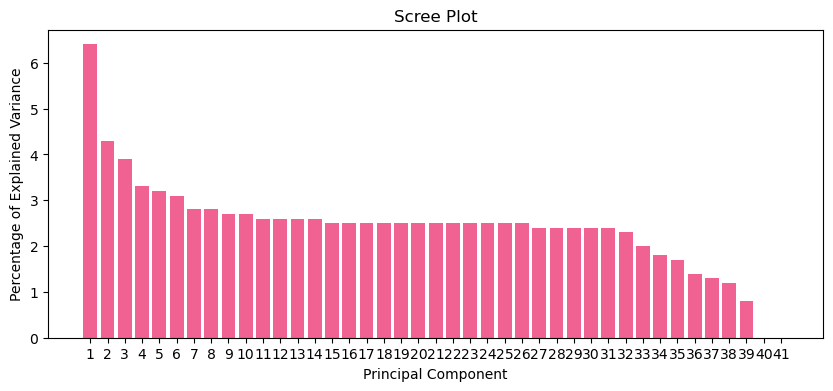

In [19]:
per_var = np.round(pca_all.explained_variance_ratio_* 100, decimals=1)
labels = [str(x) for x in range(1, len(per_var)+1)]
 
fig = plt.figure(figsize=(10, 4))
plt.bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels, color='#F06292')
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')

plt.savefig("Scree_plot.png", dpi=300, bbox_inches='tight')

plt.show()

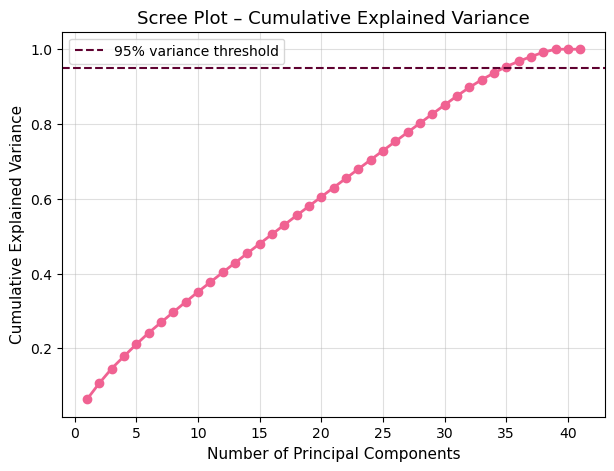

In [20]:
cum_var = np.cumsum(pca_all.explained_variance_ratio_)

plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', linewidth=2, markersize=6, color='#F06292')
plt.axhline(y=0.95, color="#5F0130", linestyle='--', label='95% variance threshold')
plt.title("Scree Plot – Cumulative Explained Variance", fontsize=13)
plt.xlabel("Number of Principal Components", fontsize=11)
plt.ylabel("Cumulative Explained Variance", fontsize=11)
plt.xticks(np.arange(0, len(cum_var)+1, 5))
plt.grid(alpha=0.4)
plt.legend()
plt.show()

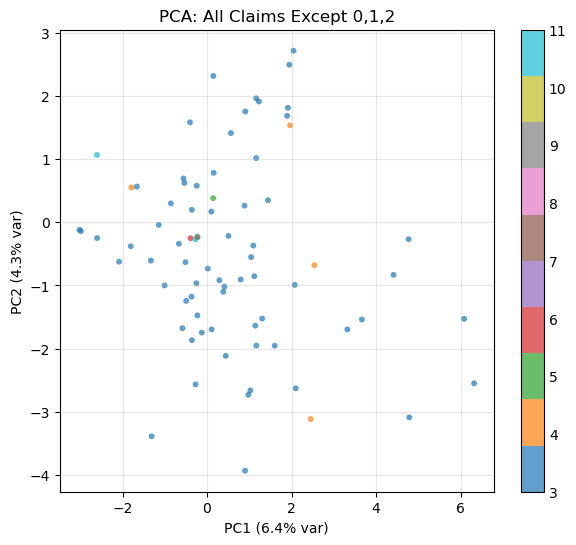

In [21]:
y_np = Y.to_numpy()
mask_np = ~np.isin(y_np, [0,1,2])

X_pca_filtered = X_all[mask_np]
Y_filtered     = y_np[mask_np]

plt.figure(figsize=(7,6))
sc = plt.scatter(
    X_pca_filtered[:, 0],
    X_pca_filtered[:, 1],
    c=Y_filtered, cmap='tab10',
    s=18, alpha=0.7, edgecolor='none'
)
cbar = plt.colorbar(sc)
cbar.ax.tick_params(width=0, length=0)
plt.xlabel(f"PC1 ({pca_all.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_all.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA: All Claims Except 0,1,2")
plt.grid(alpha=0.3)
plt.show()